In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

DATA_PATH = Path(r"C:\Users\user\cross_platform_analysis\4 - ER unified\finalData_with_er_yt_with_views.csv")
df = pd.read_csv(DATA_PATH, low_memory=False)

# Filter to 2022 only
df22 = df[df['_year'] == 2022].copy()
df22 = df22[df22['er_pct'].notna() & df22['followers'].notna()]

# Check month distribution
print("Month distribution:")
print(df22['_month'].value_counts())
print(f"\nPlatforms: {df22['_platform'].unique()}")
print(f"\nTotal records: {len(df22)}")


Month distribution:
_month
december     2989
march        2982
november     2979
september    2978
june         2953
Name: count, dtype: int64

Platforms: <StringArray>
['instagram', 'tiktok', 'youtube']
Length: 3, dtype: str

Total records: 14881


In [2]:
# Separate December (target) from training months
TRAIN_MONTHS = ['march', 'june', 'september', 'november']
TEST_MONTH = 'december'

train = df22[df22['_month'].isin(TRAIN_MONTHS)].copy()
test_ids = set(df22[df22['_month'] == TEST_MONTH]['uniqueId'].dropna())

# Compute per-creator features from training months
def compute_features(group):
    er_vals = group['er_pct'].values
    fol_vals = group['followers'].values
    months = group['_month'].values
    
    mean_er = np.mean(er_vals)
    std_er = np.std(er_vals)
    cv_er = std_er / mean_er if mean_er > 0 else np.nan
    mean_followers = np.mean(fol_vals)
    n_months = len(group)
    
    # ER trend: slope via simple linear regression if >= 2 appearances
    month_order = {'march': 1, 'june': 2, 'september': 3, 'november': 4}
    if n_months >= 2:
        x = np.array([month_order[m] for m in months])
        er_trend = np.polyfit(x, er_vals, 1)[0]
    else:
        er_trend = np.nan
    
    return pd.Series({
        'mean_er': mean_er,
        'std_er': std_er,
        'cv_er': cv_er,
        'mean_followers': mean_followers,
        'n_months': n_months,
        'er_trend': er_trend,
        'platform': group['_platform'].iloc[0],
        'category': group['category_unified'].iloc[0]
    })

features = (
    train.dropna(subset=['uniqueId'])
         .groupby('uniqueId')
         .apply(compute_features)
         .reset_index()
)

# Add target: did creator appear in December?
features['persisted'] = features['uniqueId'].isin(test_ids).astype(int)

print(f"Total creators with training data: {len(features)}")
print(f"\nPersistence rate by platform:")
print(features.groupby('platform')['persisted'].mean().round(3))
print(f"\nMissing values:\n{features.isnull().sum()}")

C:\Users\user\AppData\Local\Temp\ipykernel_136656\2126219415.py:24: RankWarning: Polyfit may be poorly conditioned
  er_trend = np.polyfit(x, er_vals, 1)[0]
C:\Users\user\AppData\Local\Temp\ipykernel_136656\2126219415.py:24: RankWarning: Polyfit may be poorly conditioned
  er_trend = np.polyfit(x, er_vals, 1)[0]
C:\Users\user\AppData\Local\Temp\ipykernel_136656\2126219415.py:24: RankWarning: Polyfit may be poorly conditioned
  er_trend = np.polyfit(x, er_vals, 1)[0]


Total creators with training data: 5045

Persistence rate by platform:
platform
instagram    0.655
tiktok       0.230
youtube      0.773
Name: persisted, dtype: float64

Missing values:
uniqueId             0
mean_er              0
std_er               0
cv_er                7
mean_followers       0
n_months             0
er_trend          2111
platform             0
category          2986
persisted            0
dtype: int64


In [3]:
# Fix missing values
features['cv_er'] = features['cv_er'].fillna(0)
features['er_trend'] = features['er_trend'].fillna(0)

# Check category coverage per platform
print("Category coverage per platform:")
print(features.groupby('platform')['category'].apply(
    lambda x: x.notna().mean()
).round(3))

# Create has_category binary flag
features['has_category'] = features['category'].notna().astype(int)

Category coverage per platform:
platform
instagram    0.902
tiktok       0.000
youtube      0.705
Name: category, dtype: float64


In [4]:
from sklearn.preprocessing import LabelEncoder

# Final feature set — no category, keep has_category
feature_cols = ['mean_er', 'std_er', 'cv_er', 'mean_followers', 
                'n_months', 'er_trend', 'has_category']

# Encode platform
le = LabelEncoder()
features['platform_enc'] = le.fit_transform(features['platform'])
feature_cols.append('platform_enc')

# Run per platform and pooled
print("Feature matrix shape:", features[feature_cols].shape)
print("\nClass distribution per platform:")
for platform in ['instagram', 'tiktok', 'youtube']:
    sub = features[features['platform'] == platform]
    n_pos = sub['persisted'].sum()
    n_neg = len(sub) - n_pos
    print(f"{platform:12s} | n={len(sub)} | persisted={n_pos} ({n_pos/len(sub)*100:.1f}%) | dropout={n_neg} ({n_neg/len(sub)*100:.1f}%)")
    

Feature matrix shape: (5045, 8)

Class distribution per platform:
instagram    | n=1375 | persisted=900 (65.5%) | dropout=475 (34.5%)
tiktok       | n=2509 | persisted=576 (23.0%) | dropout=1933 (77.0%)
youtube      | n=1161 | persisted=898 (77.3%) | dropout=263 (22.7%)


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score, 
                             confusion_matrix, classification_report)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

PLATFORMS = ['instagram', 'tiktok', 'youtube']
FEATURE_COLS = ['mean_er', 'std_er', 'cv_er', 'mean_followers',
                'n_months', 'er_trend', 'has_category']

results = []

for platform in PLATFORMS:
    print(f"\n{'='*55}")
    print(f"PLATFORM: {platform.upper()}")
    print(f"{'='*55}")
    
    sub = features[features['platform'] == platform].copy()
    X = sub[FEATURE_COLS].values
    y = sub['persisted'].values
    
    n_pos = y.sum()
    n_neg = len(y) - n_pos
    scale_pos = n_neg / n_pos
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    models = {
        'Logistic Regression': LogisticRegression(
            class_weight='balanced', random_state=42, max_iter=1000),
        'Random Forest': RandomForestClassifier(
            class_weight='balanced', n_estimators=500, random_state=42),
        'XGBoost': XGBClassifier(
            scale_pos_weight=scale_pos, n_estimators=500,
            random_state=42, eval_metric='logloss', verbosity=0),
        'SVM': SVC(
            class_weight='balanced', kernel='rbf',
            probability=True, random_state=42)
    }
    
    for name, model in models.items():
        auc  = cross_val_score(model, X_scaled, y, cv=cv,
                               scoring='roc_auc').mean()
        f1   = cross_val_score(model, X_scaled, y, cv=cv,
                               scoring='f1').mean()
        acc  = cross_val_score(model, X_scaled, y, cv=cv,
                               scoring='accuracy').mean()
        
        print(f"\n{name}")
        print(f"  AUC-ROC  = {auc:.3f}")
        print(f"  F1       = {f1:.3f}")
        print(f"  Accuracy = {acc:.3f}")
        
        results.append({
            'platform': platform, 'model': name,
            'auc': auc, 'f1': f1, 'accuracy': acc
        })

results_df = pd.DataFrame(results)
print("\n\n── Summary Table ──")
print(results_df.pivot_table(
    index='model', columns='platform', values='auc'
).round(3))


PLATFORM: INSTAGRAM

Logistic Regression
  AUC-ROC  = 0.785
  F1       = 0.782
  Accuracy = 0.727

Random Forest
  AUC-ROC  = 0.756
  F1       = 0.797
  Accuracy = 0.720

XGBoost
  AUC-ROC  = 0.714
  F1       = 0.759
  Accuracy = 0.682

SVM
  AUC-ROC  = 0.776
  F1       = 0.746
  Accuracy = 0.704

PLATFORM: TIKTOK

Logistic Regression
  AUC-ROC  = 0.800
  F1       = 0.553
  Accuracy = 0.760

Random Forest
  AUC-ROC  = 0.763
  F1       = 0.410
  Accuracy = 0.770

XGBoost
  AUC-ROC  = 0.714
  F1       = 0.422
  Accuracy = 0.727

SVM
  AUC-ROC  = 0.781
  F1       = 0.548
  Accuracy = 0.761

PLATFORM: YOUTUBE

Logistic Regression
  AUC-ROC  = 0.821
  F1       = 0.851
  Accuracy = 0.782

Random Forest
  AUC-ROC  = 0.826
  F1       = 0.891
  Accuracy = 0.825

XGBoost
  AUC-ROC  = 0.796
  F1       = 0.876
  Accuracy = 0.808

SVM
  AUC-ROC  = 0.828
  F1       = 0.822
  Accuracy = 0.754


── Summary Table ──
platform             instagram  tiktok  youtube
model                                 

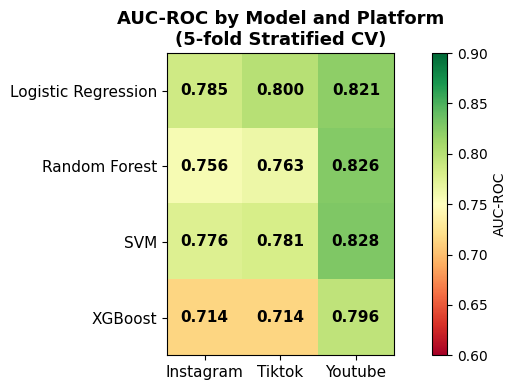

✅ Plot 1 saved


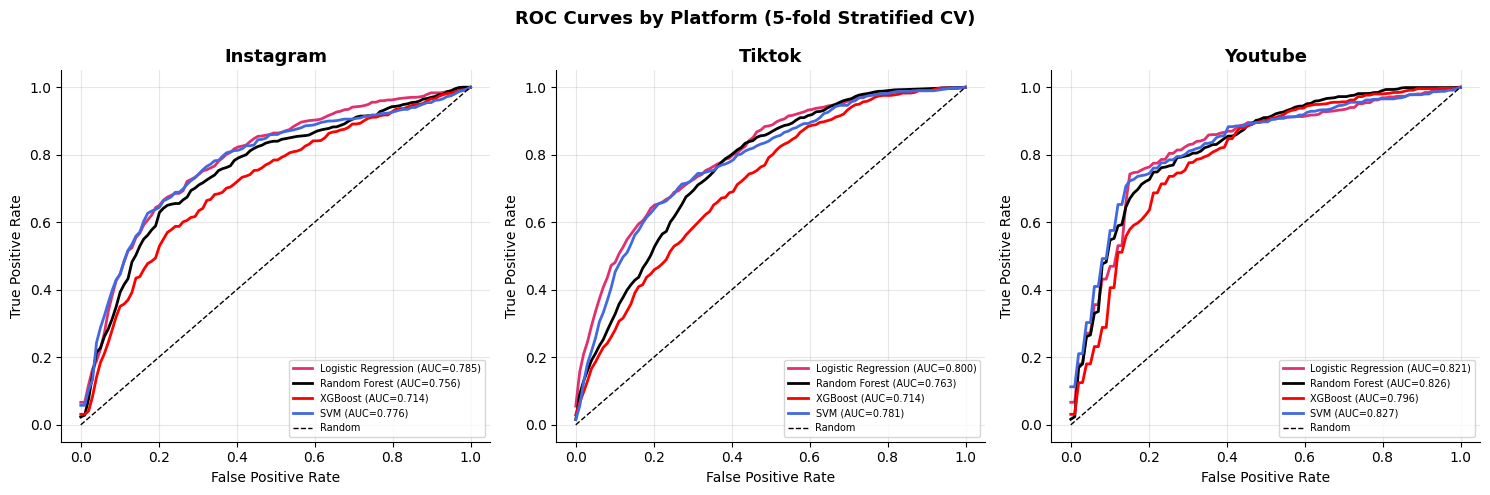

✅ Plot 2 saved


In [7]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier

from pathlib import Path
OUT_PATH = Path(r"C:\Users\user\cross_platform_analysis\8 - rq3\plots")

# ── Plot 1: AUC heatmap ───────────────────────────────────────────────────────
pivot = results_df.pivot_table(index='model', columns='platform', values='auc')
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(pivot.values, cmap='RdYlGn', vmin=0.6, vmax=0.9)
ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels([c.capitalize() for c in pivot.columns], fontsize=11)
ax.set_yticklabels(pivot.index, fontsize=11)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f"{pivot.values[i,j]:.3f}",
                ha='center', va='center', fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, label='AUC-ROC')
ax.set_title('AUC-ROC by Model and Platform\n(5-fold Stratified CV)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_PATH / 'ml_auc_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Plot 1 saved")

# ── Plot 2: ROC curves per platform ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
COLORS_ML = {
    'Logistic Regression': '#E1306C',
    'Random Forest': '#010101',
    'XGBoost': '#FF0000',
    'SVM': '#4169E1'
}

for ax, platform in zip(axes, PLATFORMS):
    sub = features[features['platform'] == platform].copy()
    X = sub[FEATURE_COLS].values
    y = sub['persisted'].values
    n_pos = y.sum()
    n_neg = len(y) - n_pos
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    models = {
        'Logistic Regression': LogisticRegression(
            class_weight='balanced', random_state=42, max_iter=1000),
        'Random Forest': RandomForestClassifier(
            class_weight='balanced', n_estimators=500, random_state=42),
        'XGBoost': XGBClassifier(
            scale_pos_weight=n_neg/n_pos, n_estimators=500,
            random_state=42, eval_metric='logloss', verbosity=0),
        'SVM': SVC(
            class_weight='balanced', kernel='rbf',
            probability=True, random_state=42)
    }
    
    for name, model in models.items():
        tprs, aucs = [], []
        mean_fpr = np.linspace(0, 1, 100)
        for train_idx, test_idx in cv.split(X_scaled, y):
            model.fit(X_scaled[train_idx], y[train_idx])
            proba = model.predict_proba(X_scaled[test_idx])[:, 1]
            fpr, tpr, _ = roc_curve(y[test_idx], proba)
            tprs.append(np.interp(mean_fpr, fpr, tpr))
            aucs.append(auc(fpr, tpr))
        mean_tpr = np.mean(tprs, axis=0)
        mean_auc = np.mean(aucs)
        ax.plot(mean_fpr, mean_tpr, color=COLORS_ML[name],
                label=f"{name} (AUC={mean_auc:.3f})", linewidth=2)
    
    ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(platform.capitalize(), fontweight='bold', fontsize=13)
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('ROC Curves by Platform (5-fold Stratified CV)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_PATH / 'ml_roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Plot 2 saved")

In [8]:
# ── SHAP beeswarm: feature importance per platform (views-inclusive) ──
import shap
import matplotlib.pyplot as plt
from pathlib import Path

OUT_PATH = Path(r"C:\Users\user\cross_platform_analysis\8 - rq3\plots")

for platform in PLATFORMS:
    sub = features[features['platform'] == platform].copy()
    X = sub[FEATURE_COLS].values
    y = sub['persisted'].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    rf = RandomForestClassifier(class_weight='balanced', n_estimators=500, random_state=42)
    rf.fit(X_scaled, y)

    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_scaled)
    # version-safe: list (old API) vs 3-D array (new API)
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values[:, :, 1]

    plt.figure(figsize=(8, 5))
    shap.summary_plot(sv, X_scaled, feature_names=FEATURE_COLS, show=False)
    plt.title(platform.capitalize(), fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUT_PATH / f'shap_{platform}.png', bbox_inches='tight', dpi=150)
    plt.close()
    print(f"OK  shap_{platform}.png saved")


OK  shap_instagram.png saved
OK  shap_tiktok.png saved
OK  shap_youtube.png saved


In [1]:
Select-String -Path "8 - rq3\scripts\rq3_analysis.py" -Pattern "DATA_PATH|finalData|yt_with"

SyntaxError: invalid syntax (3937921609.py, line 1)

In [2]:
import pandas as pd

df_orig  = pd.read_csv(r"C:\Users\user\cross_platform_analysis\4 - ER unified\finalData_with_er.csv", low_memory=False)
df_views = pd.read_csv(r"C:\Users\user\cross_platform_analysis\4 - ER unified\finalData_with_er_yt_with_views.csv", low_memory=False)

# Check Instagram and TikTok are identical
for platform in ['instagram', 'tiktok']:
    orig  = df_orig[df_orig['_platform'] == platform]['er_pct'].median()
    views = df_views[df_views['_platform'] == platform]['er_pct'].median()
    print(f"{platform} | orig median={orig:.3f} | views median={views:.3f} | same={orig==views}")

instagram | orig median=1.808 | views median=1.808 | same=True
tiktok | orig median=5.000 | views median=5.000 | same=True


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (StratifiedKFold, GridSearchCV,
                                     cross_val_score, cross_val_predict)
from sklearn.metrics import roc_curve, auc, classification_report
from xgboost import XGBClassifier

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE      = Path(r"C:\Users\user\cross_platform_analysis")
DATA_PATH = BASE / "4 - ER unified" / "finalData_with_er_yt_with_views.csv"
OUT_PATH  = BASE / "8 - rq3" / "plots"

PLATFORMS    = ['instagram', 'tiktok', 'youtube']
TRAIN_MONTHS = ['march', 'june', 'september', 'november']
TEST_MONTH   = 'december'
FEATURE_COLS = ['mean_er', 'std_er', 'cv_er', 'mean_followers',
                'n_months', 'er_trend', 'has_category']
COLORS_ML    = {
    'Logistic Regression': '#E1306C',
    'Random Forest':       '#2E86AB',
    'XGBoost':             '#FF6B35',
    'SVM':                 '#4169E1',
    'KNN':                 '#2ECC71'
}

# ── Load data ─────────────────────────────────────────────────────────────────
df   = pd.read_csv(DATA_PATH, low_memory=False)
df22 = df[df['_year'] == 2022].copy()
df22 = df22[df22['er_pct'].notna() & df22['followers'].notna()]

train    = df22[df22['_month'].isin(TRAIN_MONTHS)].copy()
test_ids = set(df22[df22['_month'] == TEST_MONTH]['uniqueId'].dropna())

# ── Feature engineering ───────────────────────────────────────────────────────
def compute_features(group):
    er_vals  = group['er_pct'].values
    fol_vals = group['followers'].values
    months   = group['_month'].values
    mean_er        = np.mean(er_vals)
    std_er         = np.std(er_vals)
    cv_er          = std_er / mean_er if mean_er > 0 else np.nan
    mean_followers = np.mean(fol_vals)
    n_months       = len(group)
    month_order    = {'march': 1, 'june': 2, 'september': 3, 'november': 4}
    if n_months >= 2:
        x        = np.array([month_order[m] for m in months])
        er_trend = np.polyfit(x, er_vals, 1)[0]
    else:
        er_trend = np.nan
    return pd.Series({
        'mean_er':        mean_er,
        'std_er':         std_er,
        'cv_er':          cv_er,
        'mean_followers': mean_followers,
        'n_months':       n_months,
        'er_trend':       er_trend,
        'platform':       group['_platform'].iloc[0],
        'category':       group['category_unified'].iloc[0]
    })

features = (
    train.dropna(subset=['uniqueId'])
         .groupby('uniqueId')
         .apply(compute_features)
         .reset_index()
)
features['persisted']    = features['uniqueId'].isin(test_ids).astype(int)
features['cv_er']        = features['cv_er'].fillna(0)
features['er_trend']     = features['er_trend'].fillna(0)
features['has_category'] = features['category'].notna().astype(int)

print("Features ready:", features.shape)
print(features.groupby('platform')['persisted'].mean().round(3))


Features ready: (5045, 11)
platform
instagram    0.655
tiktok       0.230
youtube      0.773
Name: persisted, dtype: float64


In [4]:
results_tuned = []

for platform in PLATFORMS:
    print(f"\n{'='*55}")
    print(f"PLATFORM: {platform.upper()}")
    print(f"{'='*55}")
    
    sub   = features[features['platform'] == platform].copy()
    X     = sub[FEATURE_COLS].values
    y     = sub['persisted'].values
    n_pos = y.sum()
    n_neg = len(y) - n_pos

    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    model_grids = {
        'Logistic Regression': (
            LogisticRegression(
                class_weight='balanced', random_state=42, max_iter=1000),
            {'C': [0.01, 0.1, 1, 10, 100]}
        ),
        'Random Forest': (
            RandomForestClassifier(
                class_weight='balanced', random_state=42, n_estimators=500),
            {'max_depth': [None, 5, 10, 20]}
        ),
        'XGBoost': (
            XGBClassifier(
                scale_pos_weight=n_neg/n_pos, random_state=42,
                eval_metric='logloss', verbosity=0),
            {'max_depth': [3, 5, 7],
             'learning_rate': [0.01, 0.1, 0.3],
             'n_estimators': [100, 300, 500]}
        ),
        'SVM': (
            SVC(class_weight='balanced', kernel='rbf',
                probability=True, random_state=42),
            {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto', 0.1]}
        ),
        'KNN': (
            KNeighborsClassifier(weights='distance'),
            {'n_neighbors': [3, 5, 7, 10, 15]}
        )
    }

    for name, (model, param_grid) in model_grids.items():
        grid_search = GridSearchCV(
            model, param_grid, cv=cv_inner,
            scoring='roc_auc', n_jobs=-1)
        auc_score = cross_val_score(
            grid_search, X_scaled, y,
            cv=cv_outer, scoring='roc_auc').mean()
        f1_score  = cross_val_score(
            grid_search, X_scaled, y,
            cv=cv_outer, scoring='f1').mean()
        grid_search.fit(X_scaled, y)
        best_params = grid_search.best_params_

        print(f"\n{name}")
        print(f"  AUC = {auc_score:.3f} | F1 = {f1_score:.3f}")
        print(f"  Best params: {best_params}")

        results_tuned.append({
            'platform': platform, 'model': name,
            'auc': auc_score, 'f1': f1_score,
            'best_params': best_params
        })

results_tuned_df = pd.DataFrame(results_tuned)
print("\n── Tuned AUC Summary ──")
print(results_tuned_df.pivot_table(
    index='model', columns='platform', values='auc').round(3))


PLATFORM: INSTAGRAM

Logistic Regression
  AUC = 0.785 | F1 = 0.781
  Best params: {'C': 0.1}

Random Forest
  AUC = 0.785 | F1 = 0.786
  Best params: {'max_depth': 5}

XGBoost
  AUC = 0.785 | F1 = 0.770
  Best params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}

SVM
  AUC = 0.778 | F1 = 0.776
  Best params: {'C': 1, 'gamma': 0.1}

KNN
  AUC = 0.759 | F1 = 0.796
  Best params: {'n_neighbors': 15}

PLATFORM: TIKTOK

Logistic Regression
  AUC = 0.800 | F1 = 0.554
  Best params: {'C': 0.01}

Random Forest
  AUC = 0.805 | F1 = 0.559
  Best params: {'max_depth': 5}

XGBoost
  AUC = 0.802 | F1 = 0.560
  Best params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500}

SVM
  AUC = 0.790 | F1 = 0.556
  Best params: {'C': 0.1, 'gamma': 0.1}

KNN
  AUC = 0.755 | F1 = 0.411
  Best params: {'n_neighbors': 15}

PLATFORM: YOUTUBE

Logistic Regression
  AUC = 0.824 | F1 = 0.861
  Best params: {'C': 0.01}

Random Forest
  AUC = 0.848 | F1 = 0.850
  Best params: {'max_depth':

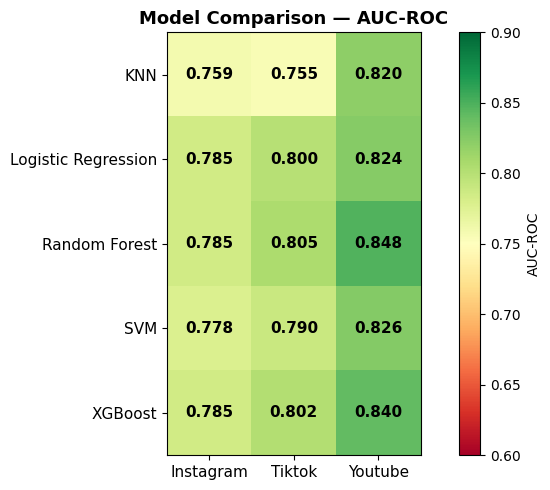

✅ Plot 1 saved


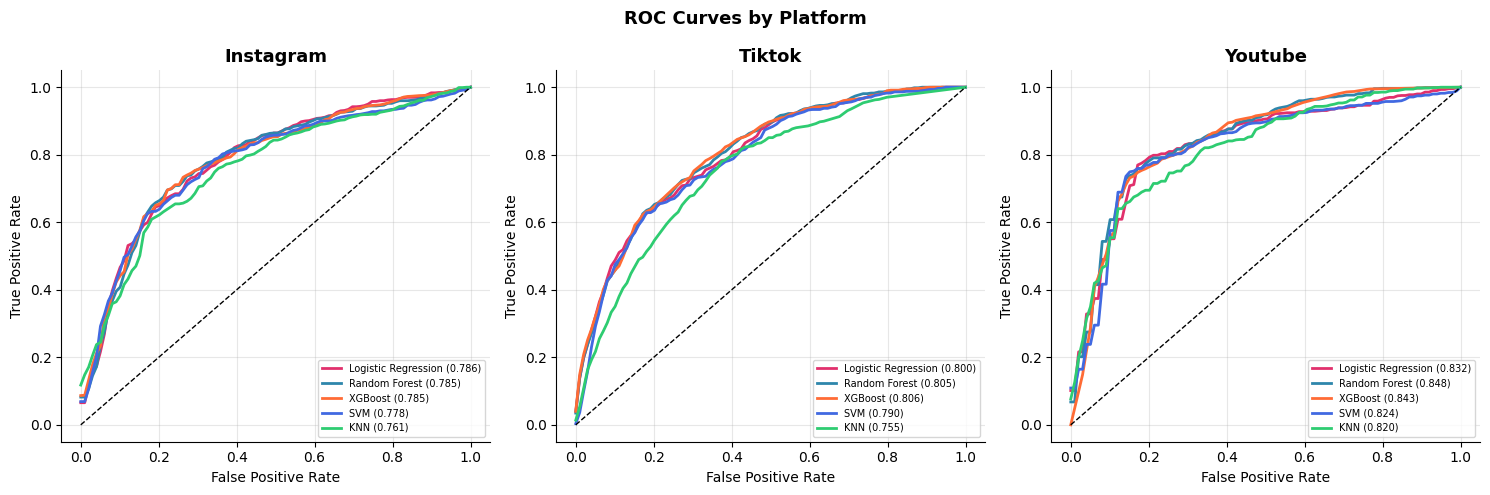

✅ Plot 2 saved


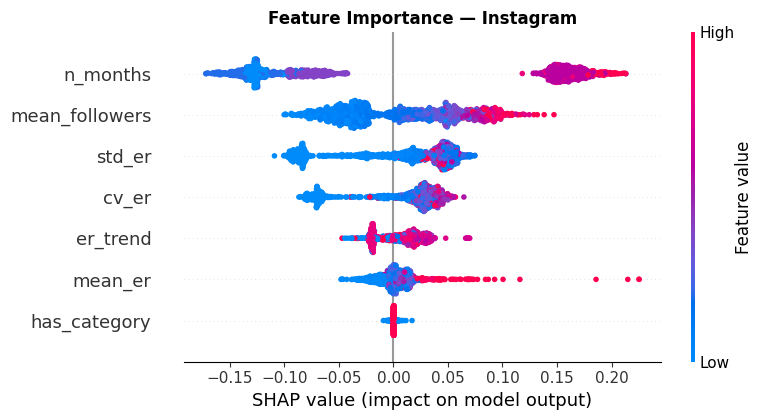

✅ SHAP saved: instagram


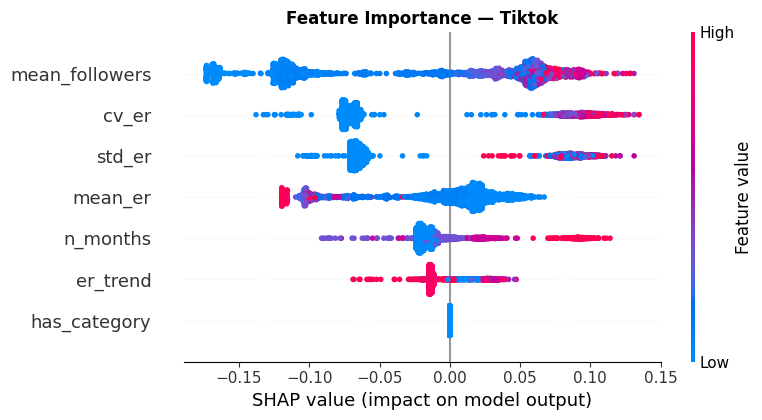

✅ SHAP saved: tiktok


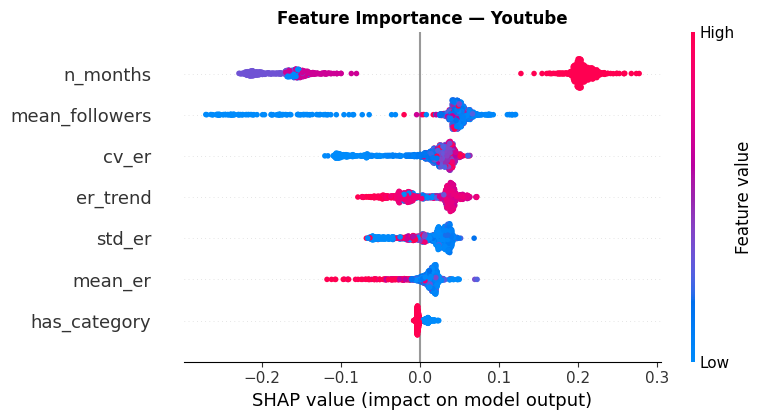

✅ SHAP saved: youtube


In [5]:
# ── Plot 1: AUC heatmap ───────────────────────────────────────────────────────
pivot = results_tuned_df.pivot_table(
    index='model', columns='platform', values='auc')
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, cmap='RdYlGn', vmin=0.6, vmax=0.9)
ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels([c.capitalize() for c in pivot.columns], fontsize=11)
ax.set_yticklabels(pivot.index, fontsize=11)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f"{pivot.values[i,j]:.3f}",
                ha='center', va='center', fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, label='AUC-ROC')
ax.set_title('Model Comparison — AUC-ROC', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_PATH / 'ml_auc_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Plot 1 saved")

# ── Plot 2: ROC curves ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, platform in zip(axes, PLATFORMS):
    sub   = features[features['platform'] == platform].copy()
    X     = sub[FEATURE_COLS].values
    y     = sub['persisted'].values
    n_pos = y.sum()
    n_neg = len(y) - n_pos

    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    cv       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    best = {r['model']: r['best_params']
            for r in results_tuned
            if r['platform'] == platform}

    models = {
        'Logistic Regression': LogisticRegression(
            class_weight='balanced', random_state=42,
            max_iter=1000, **best['Logistic Regression']),
        'Random Forest': RandomForestClassifier(
            class_weight='balanced', random_state=42,
            n_estimators=500, **best['Random Forest']),
        'XGBoost': XGBClassifier(
            scale_pos_weight=n_neg/n_pos, random_state=42,
            eval_metric='logloss', verbosity=0, **best['XGBoost']),
        'SVM': SVC(
            class_weight='balanced', kernel='rbf',
            probability=True, random_state=42, **best['SVM']),
        'KNN': KNeighborsClassifier(
            weights='distance', **best['KNN'])
    }

    for name, model in models.items():
        tprs, aucs = [], []
        mean_fpr   = np.linspace(0, 1, 100)
        for train_idx, test_idx in cv.split(X_scaled, y):
            model.fit(X_scaled[train_idx], y[train_idx])
            proba = model.predict_proba(X_scaled[test_idx])[:, 1]
            fpr, tpr, _ = roc_curve(y[test_idx], proba)
            tprs.append(np.interp(mean_fpr, fpr, tpr))
            aucs.append(auc(fpr, tpr))
        mean_tpr = np.mean(tprs, axis=0)
        mean_auc = np.mean(aucs)
        ax.plot(mean_fpr, mean_tpr, color=COLORS_ML[name],
                label=f"{name} ({mean_auc:.3f})", linewidth=2)

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(platform.capitalize(), fontweight='bold', fontsize=13)
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('ROC Curves by Platform', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_PATH / 'ml_roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Plot 2 saved")

# ── Plot 3: SHAP ──────────────────────────────────────────────────────────────
for platform in PLATFORMS:
    sub      = features[features['platform'] == platform].copy()
    X        = sub[FEATURE_COLS].values
    y        = sub['persisted'].values
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    best_rf = [r['best_params'] for r in results_tuned
               if r['platform'] == platform
               and r['model'] == 'Random Forest'][0]

    rf = RandomForestClassifier(
        class_weight='balanced', n_estimators=500,
        random_state=42, **best_rf)
    rf.fit(X_scaled, y)

    explainer   = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_scaled)
    sv = shap_values[1] if isinstance(shap_values, list) \
         else shap_values[:, :, 1]

    plt.figure(figsize=(8, 5))
    shap.summary_plot(sv, X_scaled, feature_names=FEATURE_COLS, show=False)
    plt.title(f'Feature Importance — {platform.capitalize()}',
              fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUT_PATH / f'shap_{platform}.png',
                bbox_inches='tight', dpi=150)
    plt.show()
    plt.close()
    print(f"✅ SHAP saved: {platform}")

In [6]:
perm_f_ig = perm_results['instagram']['perm_f']
print(f"Min: {perm_f_ig.min():.4f}")
print(f"Max: {perm_f_ig.max():.4f}")
print(f"Median: {np.median(perm_f_ig):.4f}")
print(f"90th percentile: {np.percentile(perm_f_ig, 90):.4f}")
print(f"99th percentile: {np.percentile(perm_f_ig, 99):.4f}")
print(f"Observed F: {perm_results['instagram']['f_stat']:.2f}")

NameError: name 'perm_results' is not defined

In [7]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import f_oneway

DATA_PATH = Path(r"C:\Users\user\cross_platform_analysis\4 - ER unified\finalData_with_er_yt_with_views.csv")
df = pd.read_csv(DATA_PATH, low_memory=False)

df22 = df[
    (df['_year'] == 2022) &
    (df['_month'] == 'december')
].copy()
df22 = df22[df22['er_pct'].notna() & df22['followers'].notna()]
df22['tier'] = df22.groupby('_platform')['followers'].transform(
    lambda x: pd.qcut(x, q=4, labels=['Q1','Q2','Q3','Q4'])
)

# Run permutation test for Instagram only
sub = df22[df22['_platform'] == 'instagram'].dropna(subset=['er_pct','tier'])
data   = sub['er_pct'].values
labels = sub['tier'].values

rng    = np.random.default_rng(42)
groups = [data[labels == l] for l in np.unique(labels)]
obs_f  = f_oneway(*groups).statistic
perm_f = np.array([
    f_oneway(*[data[rng.permutation(labels) == l]
               for l in np.unique(labels)]).statistic
    for _ in range(10000)
])

print(f"Observed F: {obs_f:.2f}")
print(f"Min: {perm_f.min():.4f}")
print(f"Median: {np.median(perm_f):.4f}")
print(f"90th pct: {np.percentile(perm_f, 90):.4f}")
print(f"99th pct: {np.percentile(perm_f, 99):.4f}")
print(f"Max: {perm_f.max():.4f}")

Observed F: 187.54
Min: 0.0002
Median: 0.6007
90th pct: 1.5731
99th pct: 2.8659
Max: 6.0714


In [8]:
ci_rows = []
for platform in PLATFORMS:
    for tier in TIER_ORDER:
        sub = df22[
            (df22['_platform'] == platform) &
            (df22['tier'] == tier)
        ]['er_pct'].dropna().values
        ci_low, ci_high = bootstrap_median_ci(sub)
        med = np.median(sub)
        ci_rows.append({
            'platform': platform, 'tier': tier,
            'median': med, 'ci_low': ci_low, 'ci_high': ci_high
        })

ci_df = pd.DataFrame(ci_rows)
print("ci_df ready")

NameError: name 'TIER_ORDER' is not defined